In [ ]:
# @title Loading PLR-YOLO blocks and datasets
import sys, json, yaml

!unzip -q "/content/drive/MyDrive/Research/HumanDetection UAV/unicamp-uav-latest.zip" -d "/content" # Unicamp UAV dataset
!unzip -q "/content/drive/MyDrive/Research/HumanDetection UAV/plr-yolo.zip" -d "/content"           # PLR-YOLO source code
!cp "/content/drive/MyDrive/Research/HumanDetection UAV/plr-yolo-unicamp-latest.pt" "/content"      # Pretrained PLR-YOLO weights

!pip install -e /content/PLR-YOLO
sys.path.append("/content/PLR-YOLO")

Obtaining file:///content/PLR-YOLO
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for ultralytics (pyproject.toml) ... done
  Created wheel for ultralytics: filename=ultralytics-8.4.41-0.editable-py3-none-any.whl size=23103 sha256=932025293a84e555880edf46eabee5d5ca98e70595b2d37d69b7143f7c50f095
  Stored in directory: /tmp/pip-ephem-wheel-cache-qbln0zw8/wheels/e2/e0/7e/85a636c7624e39400f47c4db73049b1c814213479ca82889a3
Successfully built ultralytics


In [ ]:
# @title Creating dataset.yaml for Unicamp-UAV

data_dict = {
    "train": "/content/Unicamp-UAV-All/train/images",
    "val": "/content/Unicamp-UAV-All/val/images",
    "test": "/content/Unicamp-UAV-All/test/images",

    "nc": 1,
    "names": ['Person']
}

with open("/content/dataset.yaml", "w") as f:
    yaml.dump(data_dict, f, sort_keys=False)

In [ ]:
# @title Build a fresh PLR-YOLO (that uses PPStem and LRFC3k2)

from ultralytics import YOLO

yaml_path = "/content/PLR-YOLOn.yaml"

model_dict = {
    "nc": 1,
    "end2end": True,
    "reg_max": 1,
    "scales": {
        "n": [0.5, 0.25, 512],
        "s": [0.5, 0.50, 512],
        "m": [0.5, 1.00, 512],
        "l": [1.0, 1.00, 512],
        "x": [1.0, 1.50, 512],
    },
    "backbone": [
        [-1, 1, "PPStem", [64, 2]],      # 0-P1/2
        [-1, 1, "Conv", [128, 3, 2]],     # 1-P2/4
        [-1, 2, "LRFC3k2", [256, False]],
        [-1, 1, "Conv", [256, 3, 2]],     # 3-P3/8
        [-1, 2, "LRFC3k2", [512, False]],
        [-1, 1, "Conv", [512, 3, 2]],     # 5-P4/16
        [-1, 2, "C3k2", [512, True]],
        [-1, 1, "Conv", [1024, 3, 2]],    # 7-P5/32
        [-1, 2, "C3k2", [1024, True]],
        [-1, 1, "SPPF", [1024, 5]],       # 9
        [-1, 2, "C2PSA", [1024]],         # 10
    ],
    "head": [
        [-1, 1, "nn.Upsample", [None, 2, "nearest"]],
        [[-1, 6], 1, "Concat", [1]],
        [-1, 2, "LRFC3k2", [512, True]],

        [-1, 1, "nn.Upsample", [None, 2, "nearest"]],
        [[-1, 4], 1, "Concat", [1]],
        [-1, 2, "LRFC3k2", [256, True]],  # 16 (P3)

        [-1, 1, "Conv", [256, 3, 2]],
        [[-1, 13], 1, "Concat", [1]],
        [-1, 2, "LRFC3k2", [512, True]],  # 19 (P4)

        [-1, 1, "Conv", [512, 3, 2]],
        [[-1, 10], 1, "Concat", [1]],
        [-1, 1, "C3k2", [1024, True]],    # 22 (P5)

        [[16, 19, 22], 1, "Detect", ["nc"]],
    ],
}



# Save the dictionary
with open(yaml_path, 'w') as f:
    yaml.dump(model_dict, f, sort_keys=False)

# Load the model from the newly created YAML file
# model = YOLO("yolo11n.pt")
model = YOLO(yaml_path, task="detect")
model.info()

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
WARNING ⚠️ no model scale passed. Assuming scale='n'.
PLR-YOLOn summary: 339 layers, 1,309,870 parameters, 1,309,870 gradients


(339, 1309870, 1309870, 0.0)

In [ ]:
# @title OR Load the pretrained PLR-YOLO
from ultralytics import YOLO
model = YOLO('/content/plr-yolo-unicamp-latest.pt')
model.info()

test_YOLO8n summary: 339 layers, 1,309,870 parameters, 0 gradients


(339, 1309870, 0, 0.0)

In [ ]:
# @title Parameters and FLOPs

import torch
from thop import profile, clever_format

dummy = torch.zeros(1, 3, 640, 640)

macs, params = profile(model.model, inputs=(dummy,), verbose=False)
macs_str, params_str = clever_format([macs, params], "%.3f")

print(f"Params : {params_str}")
print(f"MACs   : {macs_str}")
print(f"GFLOPs : {macs * 2 / 1e9:.2f}") 

Params : 1.310M
MACs   : 2.535G
GFLOPs : 5.07


In [ ]:
# @title PLR-YOLO evaluation on Unicamp-UAV

# Validation on the test data.
metrics = model.val(data='/content/dataset.yaml', split='test')

# Formatted table of validation metrics
metrics_table = {
    "Metric": [
        "mAP50-95",
        "mAP50",
        "mAP75",
        "Precision",
        "Recall"
    ],
    "Value": [
        metrics.box.map,
        metrics.box.map50,
        metrics.box.map75,
        metrics.box.mp,
        metrics.box.mr
    ]
}

# Display as table
from tabulate import tabulate

print(tabulate(metrics_table, headers="keys", tablefmt="grid", floatfmt=".4f"))

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
test_YOLO8n summary (fused): 160 layers, 1,210,815 parameters, 0 gradients
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3125.0±1503.3 MB/s, size: 209.4 KB)
val: Scanning /content/Unicamp-UAV-All/test/labels... 1300 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1300/1300 2.1Kit/s 0.6s
val: New cache created: /content/Unicamp-UAV-All/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 82/82 4.1it/s 19.8s
                   all       1300      12970      0.905      0.732      0.792       0.49
Speed: 1.7ms preprocess, 4.8ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /content/PLR-YOLO/runs/detect/val
+-----------+---------+
| Metric    |   Value |
+===========+=========+
| mAP50-95  |  0.4897 |
+-----------+---------+
| mAP50     |  0.7923 |
+-----------+---------+
| mAP75     |  0.5523 |
+-----------

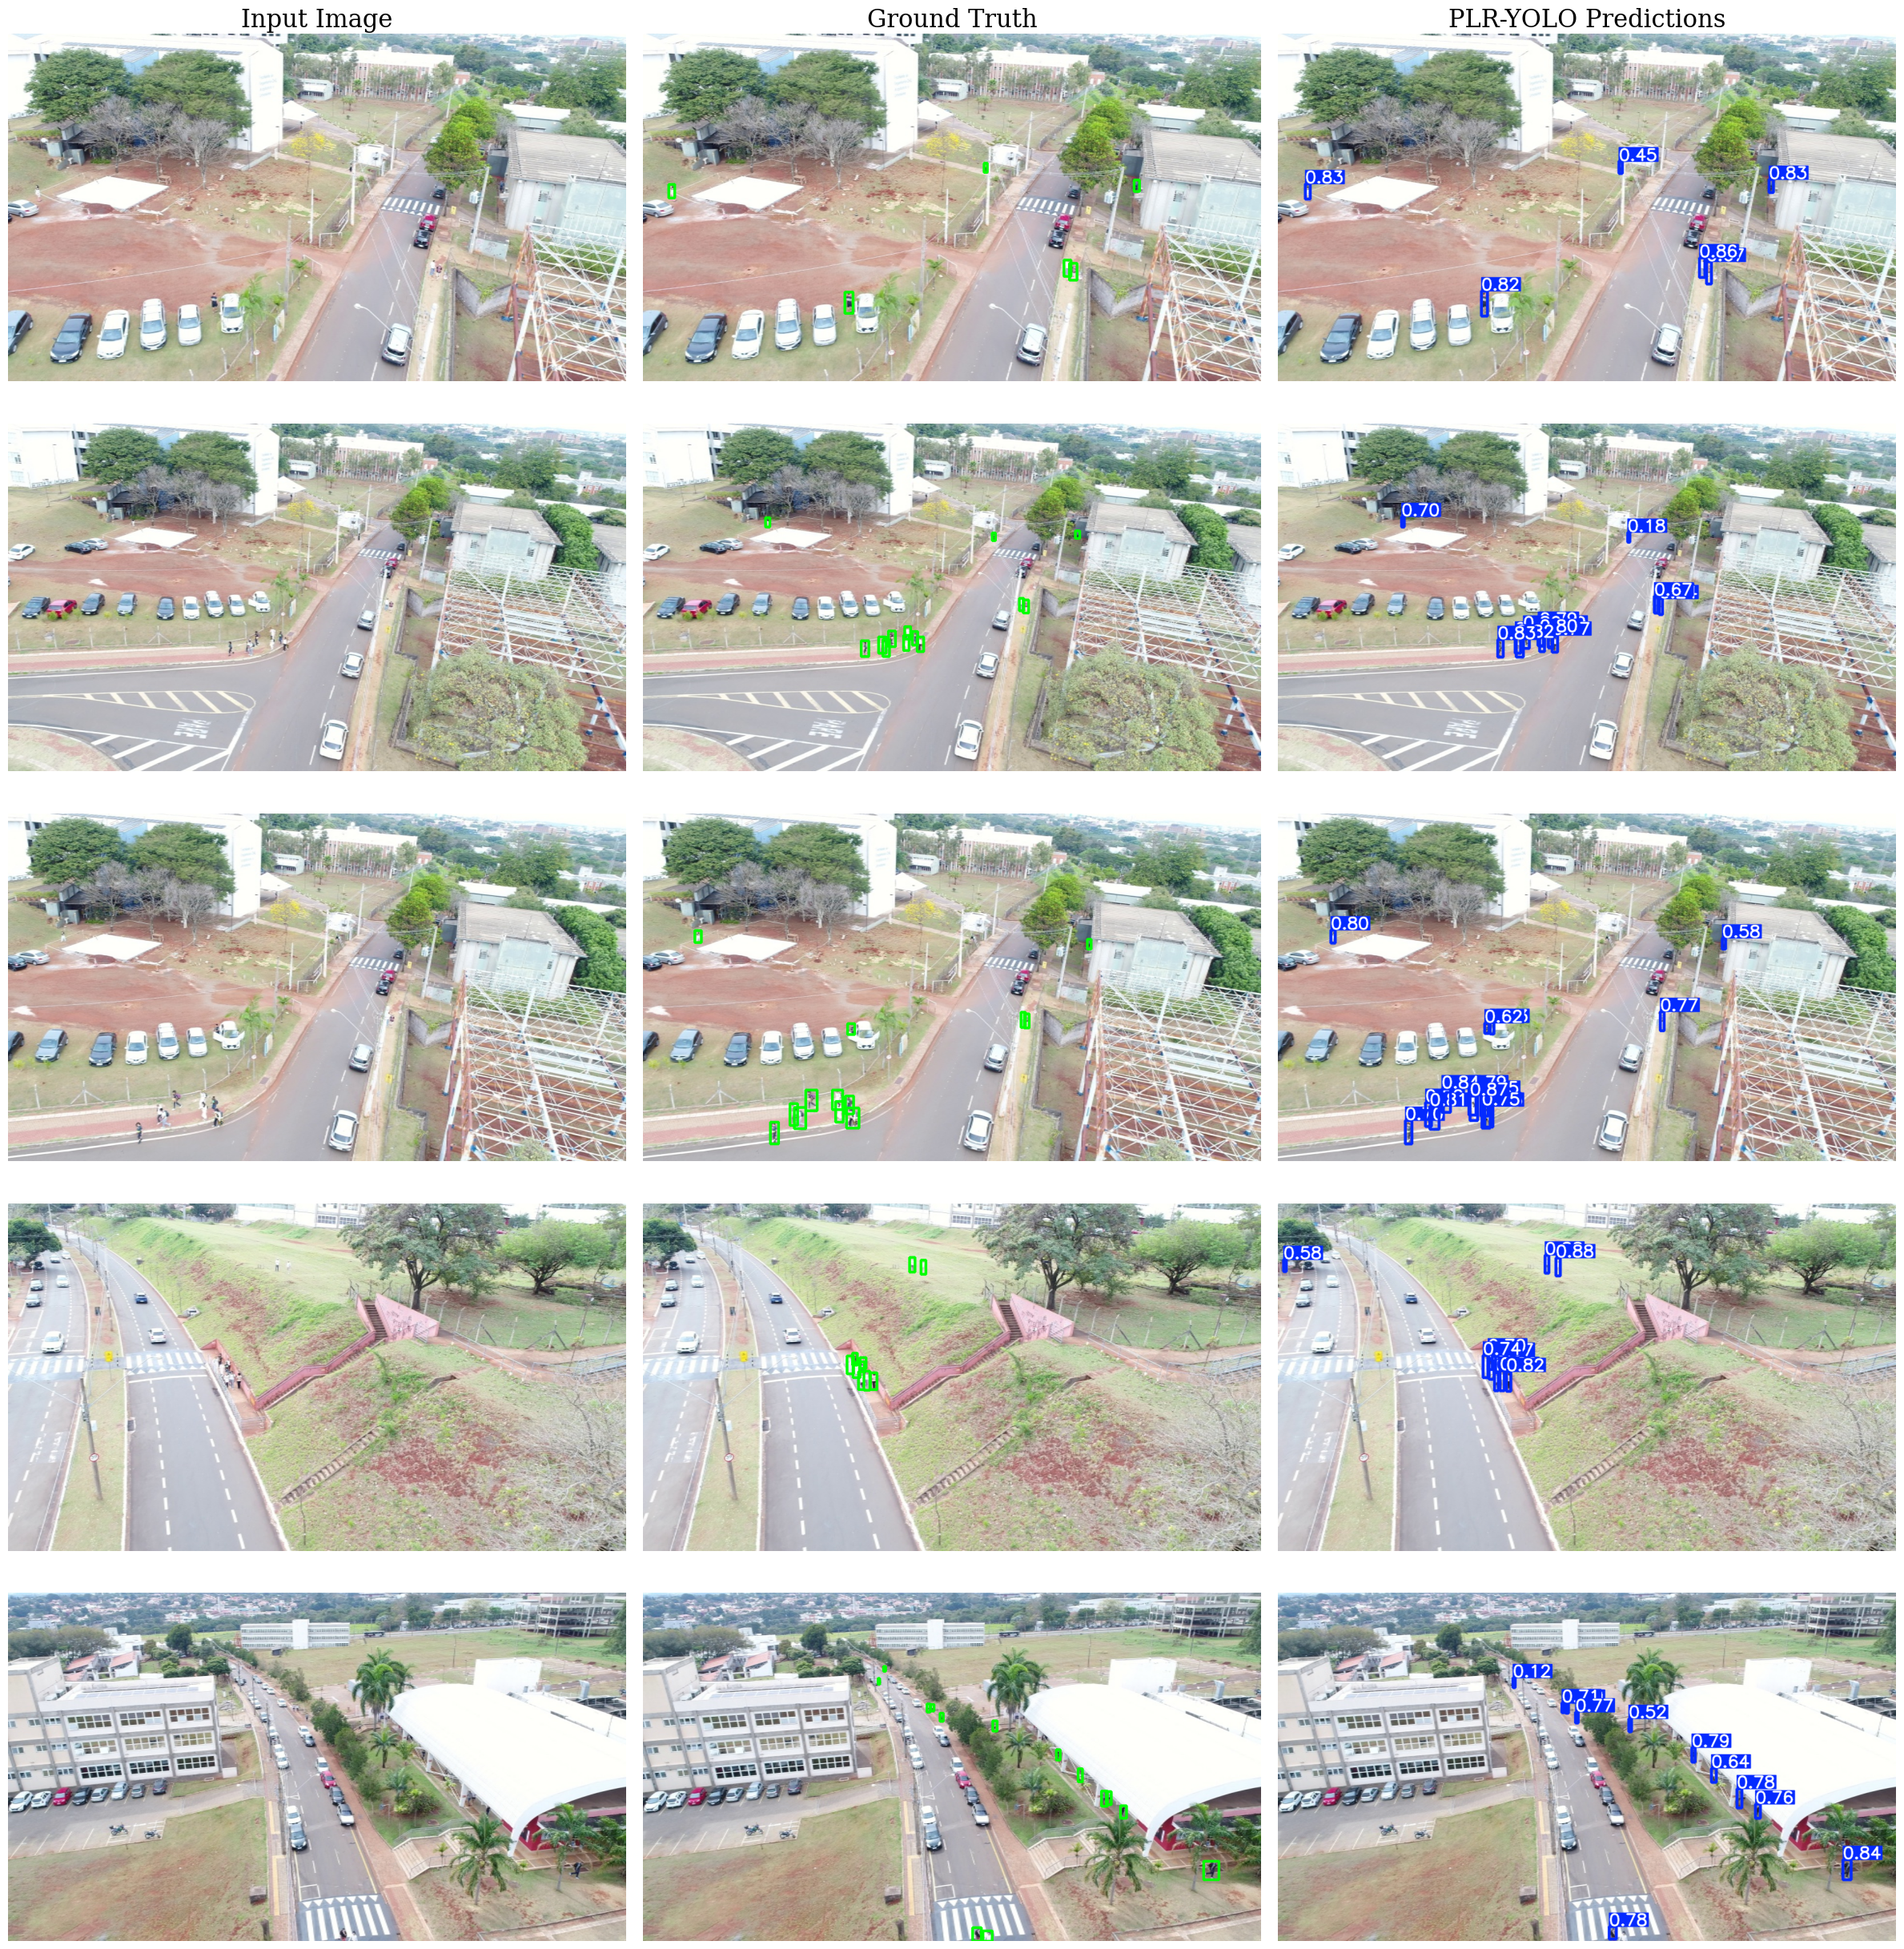

In [ ]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from pathlib import Path
import os
from PIL import Image

model = YOLO('/content/plr-yolo-unicamp-latest.pt')

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.titlesize": 18,
})

def load_yolo_labels(label_path, target_w, target_h):
    """ Loads ground truth YOLO labels and scales them to the target dimensions. """
    boxes = []
    if not os.path.exists(label_path): return []
    with open(label_path, 'r') as f:
        for line in f.readlines():
            parts = line.split()
            if not parts: continue
            _, x, y, nw, nh = map(float, parts)
            x1 = (x - nw/2) * target_w
            y1 = (y - nh/2) * target_h
            x2 = (x + nw/2) * target_w
            y2 = (y + nh/2) * target_h
            boxes.append([x1, y1, x2, y2])
    return boxes

UNICAMP_TEST_DIR = "/content/Unicamp-UAV-All/test/images"
ORIG_RES = (3840, 2160)
CONF_THRESHOLD = 0.1

x = 203
image_files = list(Path(UNICAMP_TEST_DIR).glob("*.jpg"))[x:x+5]

fig, axes = plt.subplots(len(image_files), 3, figsize=(24, 5 * len(image_files)))

for i, img_path in enumerate(image_files):
    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None: continue

    target_h = 640
    aspect_ratio = ORIG_RES[0] / ORIG_RES[1]
    target_w = int(target_h * aspect_ratio)

    img_bgr_resized = cv2.resize(img_bgr, (target_w, target_h))
    img_rgb = cv2.cvtColor(img_bgr_resized, cv2.COLOR_BGR2RGB)

    # Column 1: Input Image
    axes[i, 0].imshow(img_rgb)
    axes[i, 0].set_axis_off()
    if i == 0: axes[i, 0].set_title("Input Image", fontsize=22)

    # Column 2: Ground Truth
    label_path = str(img_path).replace("images", "labels").replace(".jpg", ".txt")
    gt_boxes = load_yolo_labels(label_path, target_w, target_h)
    gt_viz = img_rgb.copy()
    for b in gt_boxes:
        cv2.rectangle(gt_viz, (int(b[0]), int(b[1])), (int(b[2]), int(b[3])), (0, 255, 0), 3)

    axes[i, 1].imshow(gt_viz)
    axes[i, 1].set_axis_off()
    if i == 0: axes[i, 1].set_title("Ground Truth", fontsize=22)

    # Column 3: PLR-YOLO Real Predictions
    results = model.predict(source=img_bgr_resized, conf=CONF_THRESHOLD, verbose=False)


    pred_viz_bgr = results[0].plot(line_width=3, font_size=1, labels=False)
    pred_viz_rgb = cv2.cvtColor(pred_viz_bgr, cv2.COLOR_BGR2RGB)

    axes[i, 2].imshow(pred_viz_rgb)
    axes[i, 2].set_axis_off()
    if i == 0: axes[i, 2].set_title("PLR-YOLO Predictions", fontsize=22)

plt.tight_layout()
plt.show()